In [3]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt

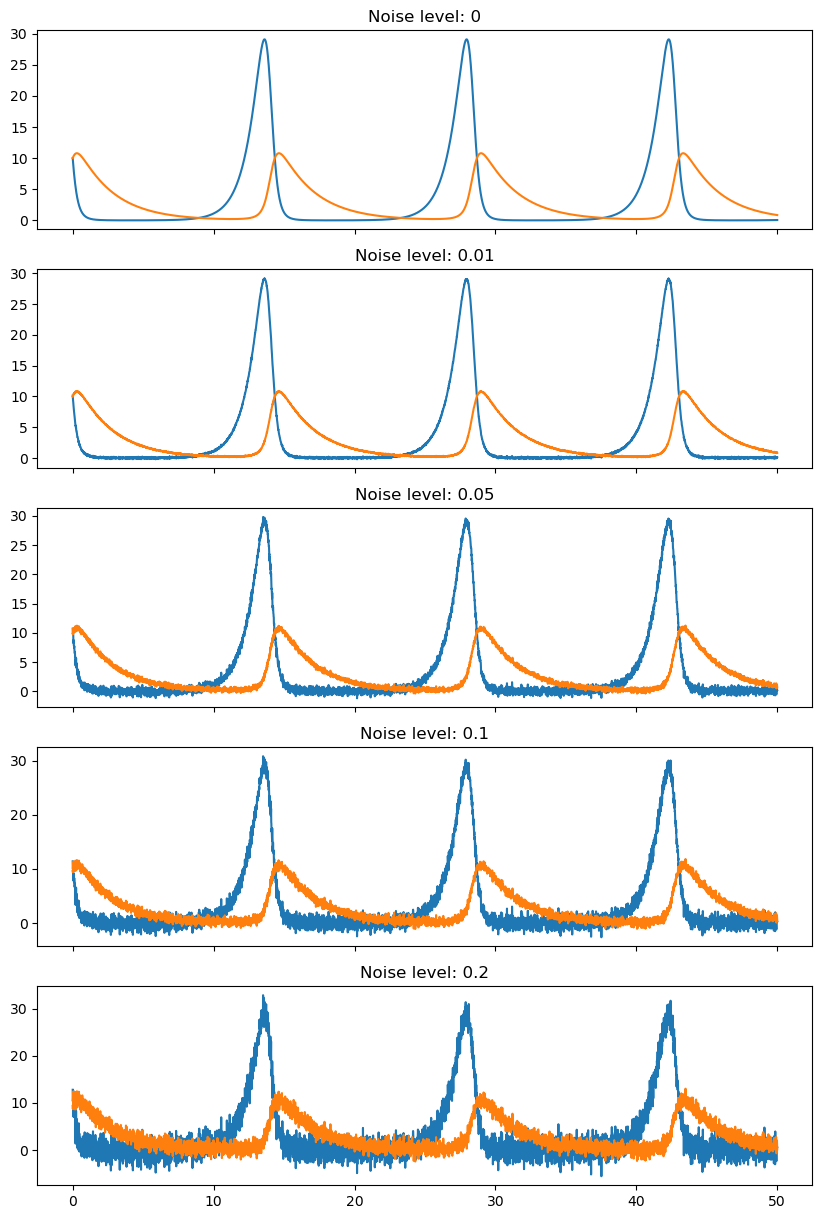

In [4]:
rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']
t_span = (0, 50)

dt = 0.01

t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

x_train = generate_training_data(rhs, x0, t_eval)

noise_levels = [0, 0.01, 0.05, 0.1, 0.2]

fig, axs = plt.subplots(len(noise_levels), 1, figsize=(10, 3*len(noise_levels)), sharex=True)

for i in range(len(noise_levels)):
    noise_level = noise_levels[i]
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    axs[i].plot(t_eval, x_train_noisy.T)
    axs[i].set_title(f"Noise level: {noise_level}")

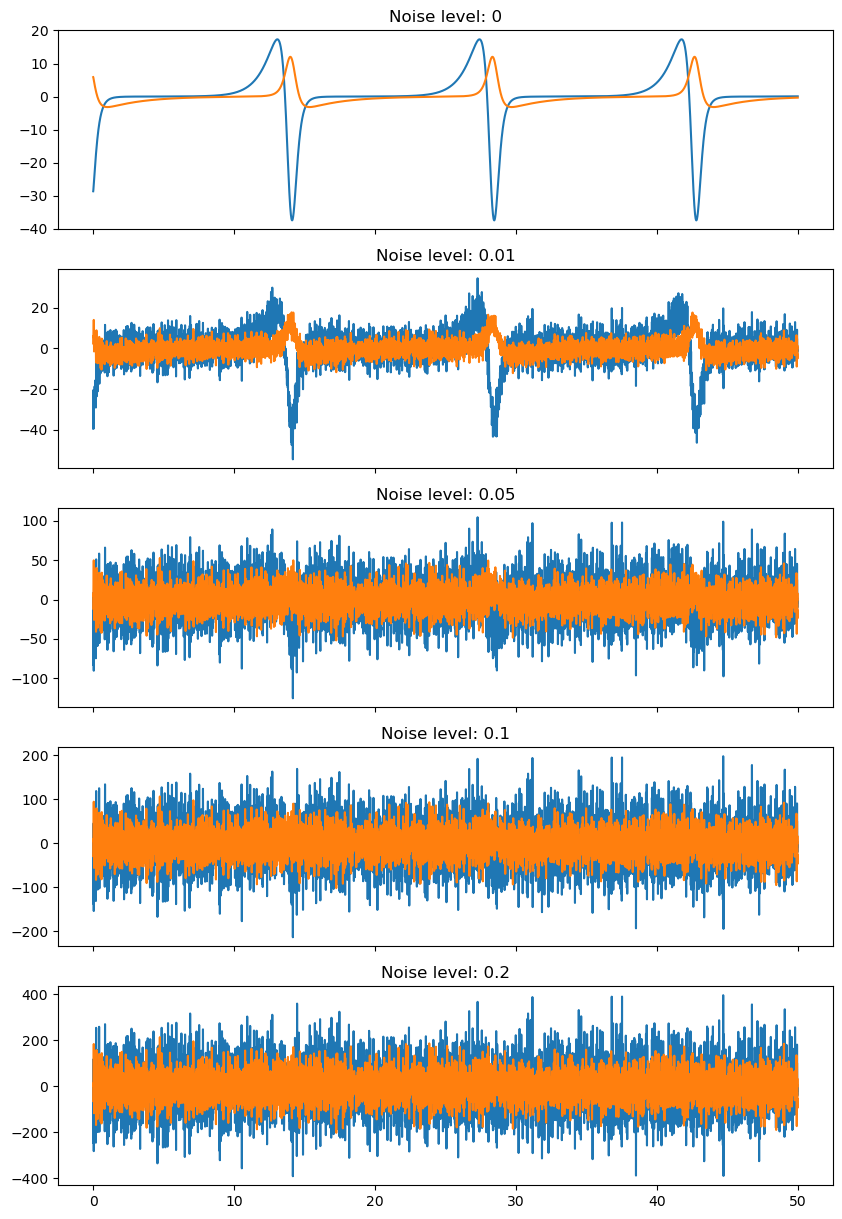

In [5]:
fig, axs = plt.subplots(len(noise_levels), 1, figsize=(10, 3*len(noise_levels)), sharex=True)

for i in range(len(noise_levels)):
    noise_level = noise_levels[i]
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    x_dot_train_noisy = dxdt_finite_difference(x_train_noisy, t_eval)

    axs[i].plot(t_eval, x_dot_train_noisy.T)
    axs[i].set_title(f"Noise level: {noise_level}")

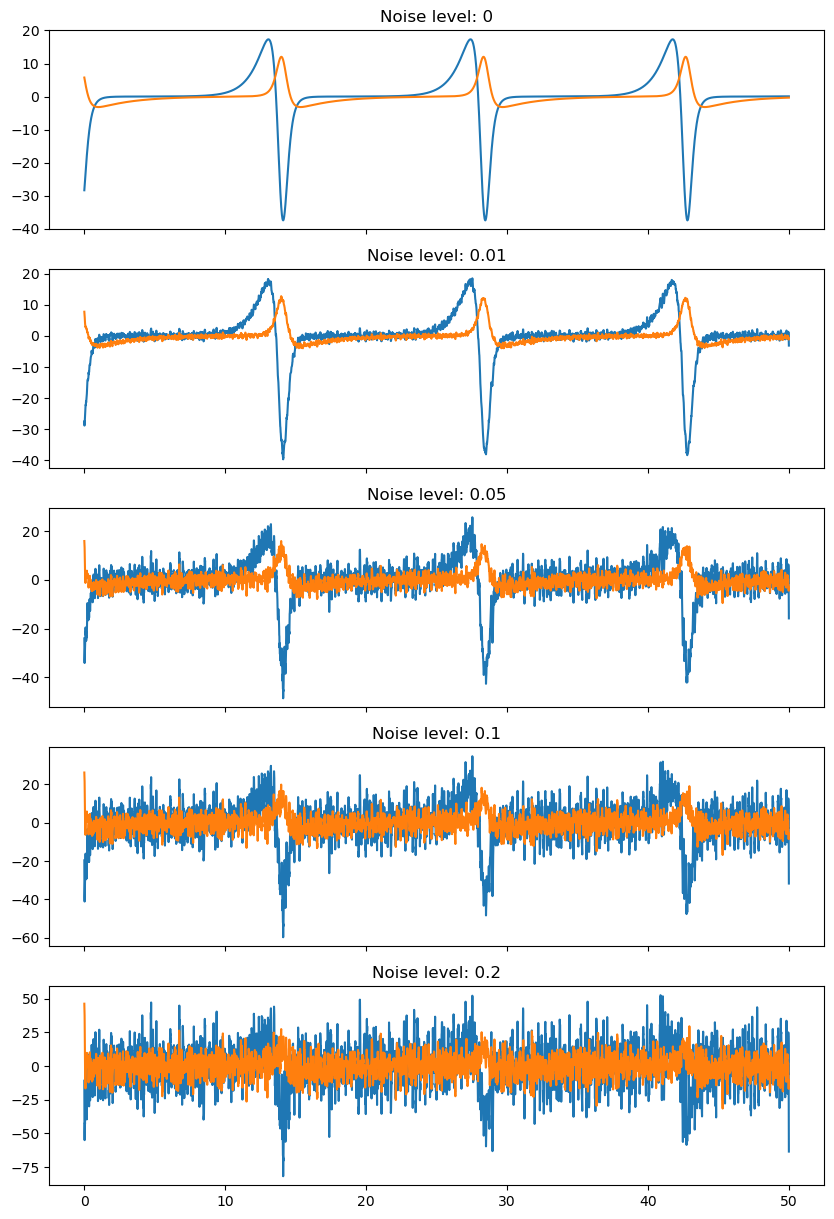

In [6]:
fig, axs = plt.subplots(len(noise_levels), 1, figsize=(10, 3*len(noise_levels)), sharex=True)

for i in range(len(noise_levels)):
    noise_level = noise_levels[i]
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    x_dot_train_noisy = dxdt_poly_fit(x_train_noisy, t_eval, poly_deg=3, window_diameter=10)

    axs[i].plot(t_eval[1:], x_dot_train_noisy.T[1:])
    axs[i].set_title(f"Noise level: {noise_level}")

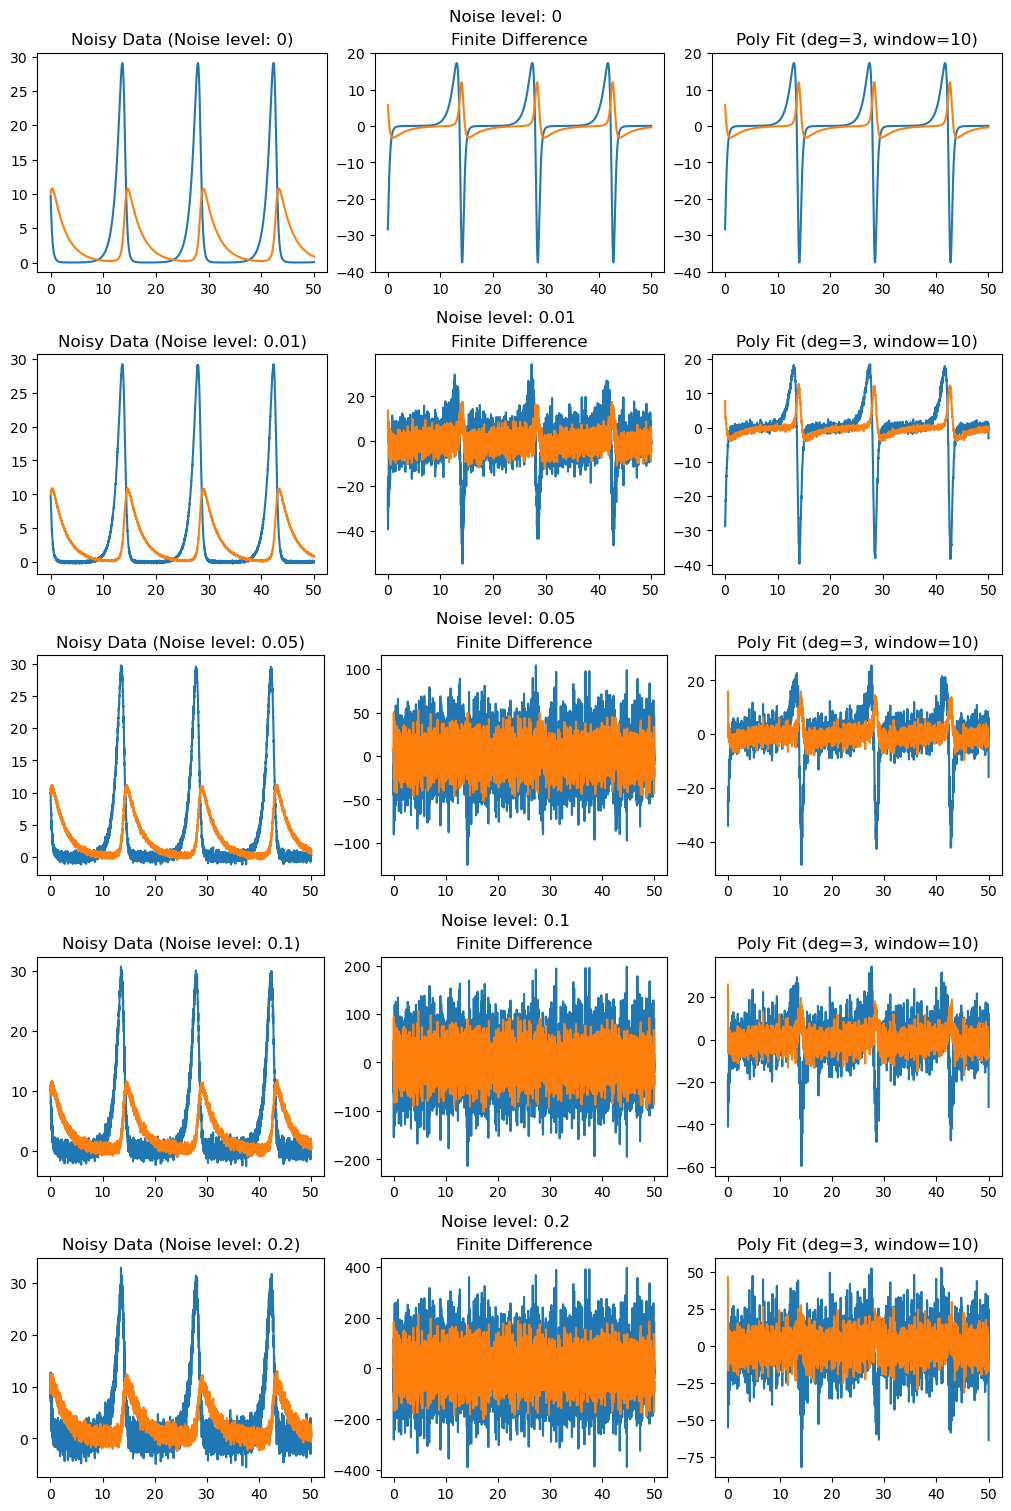

In [22]:
fig = plt.figure(constrained_layout=True, figsize=(10, 3*len(noise_levels)))
subfigs = fig.subfigures(nrows=len(noise_levels), ncols=1)

for i in range(len(noise_levels)):
    noise_level = noise_levels[i]
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    x_dot_train_noisy_fd = dxdt_finite_difference(x_train_noisy, t_eval)
    x_dot_train_noisy_poly = dxdt_poly_fit(x_train_noisy, t_eval, poly_deg=3, window_diameter=10)

    subfigs[i].suptitle(f"Noise level: {noise_level}")

    axs = subfigs[i].subplots(nrows=1, ncols=3)

    axs[0].plot(t_eval[1:], x_train_noisy.T[1:])
    axs[0].set_title(f"Noisy Data (Noise level: {noise_level})")
    axs[1].plot(t_eval[1:], x_dot_train_noisy_fd.T[1:])
    axs[1].set_title("Finite Difference")
    axs[2].plot(t_eval[1:], x_dot_train_noisy_poly.T[1:])
    axs[2].set_title("Poly Fit (deg=3, window=10)")

In [32]:
for i in range(len(noise_levels)):
    noise_level = noise_levels[i]
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    x_dot_true = rhs(t_eval, x_train)

    x_dot_train_noisy_fd = dxdt_finite_difference(x_train_noisy, t_eval)
    x_dot_train_noisy_poly = dxdt_poly_fit(x_train_noisy, t_eval, poly_deg=3, window_diameter=20)

    fd_error = np.sum(x_dot_true - x_dot_train_noisy_fd)
    poly_error = np.sum(x_dot_true - x_dot_train_noisy_poly)

    print(f"Noise level: {noise_level}")
    print(f"Finite Difference error: {fd_error}")
    print(f"Poly Fit error: {poly_error}")

Noise level: 0
Finite Difference error: -0.09715894790576991
Poly Fit error: -0.007090055287630197
Noise level: 0.01
Finite Difference error: 20.81992887847188
Poly Fit error: 2.2165749934645795
Noise level: 0.05
Finite Difference error: 104.48828018398133
Poly Fit error: 11.11123518902474
Noise level: 0.1
Finite Difference error: 209.07371931586908
Poly Fit error: 22.229560426087424
Noise level: 0.2
Finite Difference error: 418.244597579646
Poly Fit error: 44.46621096402045


In [33]:
from src.ESINDyModel import ESINDyModel

for i in range(len(noise_levels)):
    noise_level = noise_levels[i]
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    x_dot_train_noisy = dxdt_finite_difference(x_train_noisy, t_eval)
    
    model = ESINDyModel(2, 0.05)
    model.fit(x_train_noisy, x_dot_train_noisy)

    print(f'Noise level: {noise_level}')
    model.print()


for i in range(len(noise_levels)):
    noise_level = noise_levels[i]
    x_train_noisy = add_noise_to_data(x_train, noise_level)

    x_dot_train_noisy = dxdt_poly_fit(x_train_noisy, t_eval, poly_deg=3, window_diameter=20)

    model = ESINDyModel(2, 0.05)
    model.fit(x_train_noisy, x_dot_train_noisy)

    print(f'Noise level: {noise_level}')
    model.print()

Noise level: 0
x0' = + 1.09989 x0 + -0.39996 x0 x1 
x1' = + -0.39998 x1 + 0.09999 x0 x1 
Noise level: 0.01
x0' = + 1.09405 x0 + -0.39963 x0 x1 
x1' = + -0.39780 x1 + 0.10006 x0 x1 
Noise level: 0.05
x0' = + 1.07396 x0 + -0.39512 x0 x1 
x1' = + -0.38608 x1 + 0.09879 x0 x1 
Noise level: 0.1
x0' = + 1.00733 x0 + -0.37123 x0 x1 
x1' = + -0.26088 x1 + 0.09682 x0 x1 
Noise level: 0.2
x0' = + 0.39730 1 + 0.81465 x0 + 0.18851 x1 + -0.29526 x0 x1 + -0.08248 x1^2 
x1' = + -0.09000 1 + 0.06838 x0 + -0.09374 x1 + 0.07857 x0 x1 
Noise level: 0
x0' = + 1.09974 x0 + -0.39991 x0 x1 
x1' = + -0.39995 x1 + 0.09999 x0 x1 
Noise level: 0.01
x0' = + 1.09928 x0 + -0.40028 x0 x1 
x1' = + -0.39974 x1 + 0.10018 x0 x1 
Noise level: 0.05
x0' = + 1.08765 x0 + -0.39811 x0 x1 
x1' = + -0.39673 x1 + 0.10030 x0 x1 
Noise level: 0.1
x0' = + 1.04967 x0 + -0.38612 x0 x1 
x1' = + -0.38644 x1 + 0.09887 x0 x1 
Noise level: 0.2
x0' = + 0.52441 1 + 0.88786 x0 + -0.18678 x1 + -0.33088 x0 x1 
x1' = + -0.90577 1 
